In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, ttest_ind

class movies:
    def __init__(self, df=None, filename=None):
        if filename:
            self.df = pd.read_csv(filename)
        elif df is not None:
            self.df = df
        else:
            raise ValueError("Provide either a DataFrame or a filename.")

    def head(self, n=5):
        return self.df.head(n)

    def tail(self, n=5):
        return self.df.tail(n)

    def shape(self):
        return self.df.shape
        
    def columns(self):
        return self.df.columns.tolist()

    def info(self):
        return self.df.dtypes

    def describe(self):
        return self.df.describe(include='all')

    def unique_counts(self):
        return self.df.nunique()

    def categorical_summary(self):
        return self.df.describe(include='object')

    def null_counts(self):
        return self.df.isnull().sum()

    def null_percentage(self):
        return (self.df.isnull().mean() * 100).round(2)

    def duplicates(self):
        return self.df[self.df.duplicated()]

    def fillna_with_mode(self, col):
        if col in self.df.columns:
            if self.df[col].isnull().sum() > 0:
                mode_val = self.df[col].mode()[0]
                self.df[col] = self.df[col].fillna(mode_val)

    def drop_nulls(self):
        self.df.dropna(inplace=True)

    def drop_duplicates(self):
        self.df.drop_duplicates(inplace=True)

    def drop_column(self, col):
        if col in self.df.columns:
            self.df.drop(columns=[col], inplace=True)

    def convert_dtype(self, col, dtype):
        if col in self.df.columns:
            self.df[col] = self.df[col].astype(dtype)


    def detect_outliers(self, column):
        col = pd.to_numeric(self.df[column], errors='coerce').dropna()
        Q1 = col.quantile(0.25)
        Q3 = col.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = self.df[(self.df[column] < lower) | (self.df[column] > upper)]
        return outliers[column].tolist()


    def plot_distribution(self, column):
        plt.figure(figsize=(8, 4))
        sns.histplot(self.df[column].dropna(), kde=True)
        plt.title(f"Distribution of {column}")
        plt.show()

    def plot_count(self, column):
        plt.figure(figsize=(8, 4))
        sns.countplot(x=self.df[column])
        plt.title(f"Count Plot of {column}")
        plt.xticks(rotation=45)
        plt.show()

    def box_plot(self, column):
        plt.figure(figsize=(6, 4))
        sns.boxplot(y=self.df[column], color='skyblue')
        plt.title(f'Boxplot of {column}')
        plt.show()

    def plot_pie(self, column):
        self.df[column].value_counts().plot.pie(autopct="%1.1f%%", figsize=(6, 6))
        plt.title(f"Pie Chart of {column}")
        plt.ylabel('')
        plt.show()

    def plot_bar(self, column):
        self.df[column].value_counts().plot.bar(figsize=(8, 4))
        plt.title(f"Bar Chart of {column}")
        plt.xticks(rotation=45)
        plt.show()

    def plot_scatter(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=self.df[x], y=self.df[y])
        plt.title(f"Scatter Plot: {x} vs {y}")
        plt.show()

    def plot_line(self, x, y):
        plt.figure(figsize=(8, 4))
        sns.lineplot(x=self.df[x], y=self.df[y])
        plt.title(f"Line Plot: {x} vs {y}")
        plt.show()

    def correlation_heatmap(self):
        plt.figure(figsize=(10, 8))
        sns.heatmap(self.df.corr(numeric_only=True), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap")
        plt.show()

    def chi_square(self, col1, col2):
        table = pd.crosstab(self.df[col1], self.df[col2])
        _, p, _, _ = chi2_contingency(table)
        return p

    def continuous_correlations(self):
        corr_matrix = self.df.select_dtypes(include=['int64', 'float64']).corr()
        correlated_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
                corr_value = corr_matrix.iloc[i, j]
                correlated_pairs.append((col1, col2, corr_value))
        return sorted(correlated_pairs, key=lambda x: abs(x[2]), reverse=True)

    def anova_test(self, target):
        results = []
        if target not in self.df.columns:
            return pd.DataFrame()
        categorical_cols = self.df.select_dtypes(include='object').columns
        for cat in categorical_cols:
            if self.df[cat].nunique() > 1:
                groups = [group[target].dropna().values
                          for _, group in self.df.groupby(cat) if len(group[target].dropna()) > 1]
                if len(groups) > 1:
                    stat, p = f_oneway(*groups)
                    results.append({'Feature': cat, 'ANOVA_p_value': round(p, 4)})
        return pd.DataFrame(results)

    def t_test(self, cat_col, target):
        groups = self.df[cat_col].dropna().unique()
        if len(groups) != 2:
            raise ValueError("T-test is only applicable for binary categorical variables")
        group1 = self.df[self.df[cat_col] == groups[0]][target].dropna()
        group2 = self.df[self.df[cat_col] == groups[1]][target].dropna()
        _, p = ttest_ind(group1, group2)
        return p


    def save_to_csv(self, filename):
        self.df.to_csv(filename, index=False)


In [41]:
movies_df=movies(filename="Movie+Assignment+Data.csv")

In [6]:
movies_df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [7]:
movies_df.tail()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,NaN,Comedy|Drama,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,841.0,NaN,Crime|Drama|Mystery|Thriller,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,NaN,Drama|Horror|Thriller,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Comedy|Drama|Romance,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660
5042,Color,Jon Gunn,43.0,90.0,16.0,16.0,Brian Herzlinger,86.0,85222.0,Documentary,...,84.0,English,USA,PG,1100.0,2004.0,23.0,6.6,1.85,456


In [8]:
movies_df.shape()

(5043, 28)

In [9]:
movies_df.columns()

['color',
 'director_name',
 'num_critic_for_reviews',
 'duration',
 'director_facebook_likes',
 'actor_3_facebook_likes',
 'actor_2_name',
 'actor_1_facebook_likes',
 'gross',
 'genres',
 'actor_1_name',
 'movie_title',
 'num_voted_users',
 'cast_total_facebook_likes',
 'actor_3_name',
 'facenumber_in_poster',
 'plot_keywords',
 'movie_imdb_link',
 'num_user_for_reviews',
 'language',
 'country',
 'content_rating',
 'budget',
 'title_year',
 'actor_2_facebook_likes',
 'imdb_score',
 'aspect_ratio',
 'movie_facebook_likes']

In [10]:
movies_df.info

color                         object
director_name                 object
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_2_name                  object
actor_1_facebook_likes       float64
gross                        float64
genres                        object
actor_1_name                  object
movie_title                   object
num_voted_users                int64
cast_total_facebook_likes      int64
actor_3_name                  object
facenumber_in_poster         float64
plot_keywords                 object
movie_imdb_link               object
num_user_for_reviews         float64
language                      object
country                       object
content_rating                object
budget                       float64
title_year                   float64
actor_2_facebook_likes       float64
imdb_score                   float64
aspect_ratio                 float64
m

In [11]:
movies_df.describe()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,5024,4939,4993.000000,5028.000000,4939.000000,5020.000000,5030,5036.000000,4.159000e+03,5043,...,5022.000000,5029,5038,4740,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
unique,2,2398,NaN,NaN,NaN,NaN,3032,NaN,NaN,914,...,NaN,46,65,18,NaN,NaN,NaN,NaN,NaN,NaN
top,Color,Steven Spielberg,NaN,NaN,NaN,NaN,Morgan Freeman,NaN,NaN,Drama,...,NaN,English,USA,R,NaN,NaN,NaN,NaN,NaN,NaN
freq,4815,26,NaN,NaN,NaN,NaN,20,NaN,NaN,236,...,NaN,4704,3807,2118,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,140.194272,107.201074,686.509212,645.009761,NaN,6560.047061,4.846841e+07,NaN,...,272.770808,NaN,NaN,NaN,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,NaN,NaN,121.601675,25.197441,2813.328607,1665.041728,NaN,15020.759120,6.845299e+07,NaN,...,377.982886,NaN,NaN,NaN,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,NaN,NaN,1.000000,7.000000,0.000000,0.000000,NaN,0.000000,1.620000e+02,NaN,...,1.000000,NaN,NaN,NaN,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,NaN,NaN,50.000000,93.000000,7.000000,133.000000,NaN,614.000000,5.340988e+06,NaN,...,65.000000,NaN,NaN,NaN,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,NaN,NaN,110.000000,103.000000,49.000000,371.500000,NaN,988.000000,2.551750e+07,NaN,...,156.000000,NaN,NaN,NaN,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,NaN,NaN,195.000000,118.000000,194.500000,636.000000,NaN,11000.000000,6.230944e+07,NaN,...,326.000000,NaN,NaN,NaN,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000


In [12]:
movies_df.unique_counts()

color                           2
director_name                2398
num_critic_for_reviews        528
duration                      191
director_facebook_likes       435
actor_3_facebook_likes        906
actor_2_name                 3032
actor_1_facebook_likes        878
gross                        4035
genres                        914
actor_1_name                 2097
movie_title                  4917
num_voted_users              4826
cast_total_facebook_likes    3978
actor_3_name                 3521
facenumber_in_poster           19
plot_keywords                4760
movie_imdb_link              4919
num_user_for_reviews          954
language                       46
country                        65
content_rating                 18
budget                        439
title_year                     91
actor_2_facebook_likes        917
imdb_score                     78
aspect_ratio                   22
movie_facebook_likes          876
dtype: int64

In [13]:
movies_df.categorical_summary()

,color,director_name,actor_2_name,genres,actor_1_name,movie_title,actor_3_name,plot_keywords,movie_imdb_link,language,country,content_rating
count,5024,4939,5030,5043,5036,5043,5020,4890,5043,5029,5038,4740
unique,2,2398,3032,914,2097,4917,3521,4760,4919,46,65,18
top,Color,Steven Spielberg,Morgan Freeman,Drama,Robert De Niro,Ben-Hur,John Heard,based on novel,http://www.imdb.com/title/tt0232500/?ref_=fn_t...,English,USA,R
freq,4815,26,20,236,49,3,8,4,3,4704,3807,2118


In [14]:
movies_df.null_counts()

color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  23
facenumber_in_poster          13
plot_keywords                153
movie_imdb_link                0
num_user_for_reviews          21
language                      14
country                        5
content_rating               303
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
dtype: int64

In [15]:
movies_df.null_percentage()

color                         0.38
director_name                 2.06
num_critic_for_reviews        0.99
duration                      0.30
director_facebook_likes       2.06
actor_3_facebook_likes        0.46
actor_2_name                  0.26
actor_1_facebook_likes        0.14
gross                        17.53
genres                        0.00
actor_1_name                  0.14
movie_title                   0.00
num_voted_users               0.00
cast_total_facebook_likes     0.00
actor_3_name                  0.46
facenumber_in_poster          0.26
plot_keywords                 3.03
movie_imdb_link               0.00
num_user_for_reviews          0.42
language                      0.28
country                       0.10
content_rating                6.01
budget                        9.76
title_year                    2.14
actor_2_facebook_likes        0.26
imdb_score                    0.00
aspect_ratio                  6.52
movie_facebook_likes          0.00
dtype: float64

In [16]:
movies_df.duplicates()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
137,Color,David Yates,248.0,110.0,282.0,103.0,Alexander Skarsgård,11000.0,124051759.0,Action|Adventure|Drama|Romance,...,239.0,English,USA,PG-13,180000000.0,2016.0,10000.0,6.6,2.35,29000
187,Color,Bill Condon,322.0,115.0,386.0,12000.0,Kristen Stewart,21000.0,292298923.0,Adventure|Drama|Fantasy|Romance,...,329.0,English,USA,PG-13,120000000.0,2012.0,17000.0,5.5,2.35,65000
204,Color,Hideaki Anno,1.0,120.0,28.0,12.0,Shin'ya Tsukamoto,544.0,NaN,Action|Adventure|Drama|Horror|Sci-Fi,...,13.0,Japanese,Japan,NaN,NaN,2016.0,106.0,8.2,2.35,0
303,Color,Joe Wright,256.0,111.0,456.0,394.0,Cara Delevingne,20000.0,34964818.0,Adventure|Family|Fantasy,...,186.0,English,USA,PG,150000000.0,2015.0,548.0,5.8,2.35,24000
389,Color,Josh Trank,369.0,100.0,128.0,78.0,Reg E. Cathey,596.0,56114221.0,Action|Adventure|Sci-Fi,...,695.0,English,USA,PG-13,120000000.0,2015.0,360.0,4.3,2.35,41000
395,Color,Rob Cohen,187.0,106.0,357.0,4000.0,Vin Diesel,23000.0,144512310.0,Action|Crime|Thriller,...,988.0,English,USA,PG-13,38000000.0,2001.0,14000.0,6.7,2.35,14000
590,Color,Brett Ratner,245.0,101.0,420.0,467.0,Rufus Sewell,12000.0,72660029.0,Action|Adventure,...,269.0,English,USA,PG-13,100000000.0,2014.0,3000.0,6.0,2.35,21000
656,Color,Paul Verhoeven,196.0,113.0,719.0,217.0,Rachel Ticotin,605.0,119412921.0,Action|Sci-Fi,...,391.0,English,USA,R,65000000.0,1990.0,308.0,7.5,1.85,0
794,Color,Joss Whedon,703.0,173.0,0.0,19000.0,Robert Downey Jr.,26000.0,623279547.0,Action|Adventure|Sci-Fi,...,1722.0,English,USA,PG-13,220000000.0,2012.0,21000.0,8.1,1.85,123000
1220,Color,Angelina Jolie Pitt,322.0,137.0,11000.0,465.0,Jack O'Connell,769.0,115603980.0,Biography|Drama|Sport|War,...,351.0,English,USA,PG-13,65000000.0,2014.0,698.0,7.2,2.35,35000


In [17]:
movies_df.drop_nulls()

In [18]:
movies_df.drop_duplicates()

In [19]:
movies_df.duplicates()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes


In [20]:
movies_df.convert_dtype("budget", float)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,2.370000e+08,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,3.000000e+08,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,2.450000e+08,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,2.500000e+08,2012.0,23000.0,8.5,2.35,164000
5,Color,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,...,738.0,English,USA,PG-13,2.637000e+08,2012.0,632.0,6.6,2.35,24000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4128,Color,Tim Burton,451.0,108.0,13000.0,11000.0,Alan Rickman,40000.0,334185206.0,Adventure|Family|Fantasy,...,736.0,English,USA,PG,2.000000e+08,2010.0,25000.0,6.5,1.85,24000
4542,Color,Takao Okawara,107.0,99.0,2.0,3.0,Naomi Nishida,43.0,10037390.0,Action|Adventure|Drama|Sci-Fi|Thriller,...,140.0,Japanese,Japan,PG,1.000000e+09,1999.0,3.0,6.0,2.35,339
4694,Color,Peter Jackson,446.0,201.0,0.0,84.0,Thomas Kretschmann,6000.0,218051260.0,Action|Adventure|Drama|Romance,...,2618.0,English,New Zealand,PG-13,2.070000e+08,2005.0,918.0,7.2,2.35,0
4752,Color,Tim Johnson,165.0,94.0,12.0,183.0,Matt Jones,17000.0,177343675.0,Adventure|Animation|Comedy|Family|Fantasy|Sci-Fi,...,214.0,English,USA,PG,1.350000e+08,2015.0,523.0,6.7,1.85,26000


In [26]:
movies_df.detect_outliers("budget")

[237000000.0,
 300000000.0,
 245000000.0,
 250000000.0,
 263700000.0,
 258000000.0,
 260000000.0,
 250000000.0,
 250000000.0,
 250000000.0,
 209000000.0,
 200000000.0,
 225000000.0,
 215000000.0,
 225000000.0,
 225000000.0,
 220000000.0,
 250000000.0,
 225000000.0,
 250000000.0,
 230000000.0,
 200000000.0,
 225000000.0,
 180000000.0,
 207000000.0,
 200000000.0,
 250000000.0,
 209000000.0,
 150000000.0,
 200000000.0,
 200000000.0,
 200000000.0,
 200000000.0,
 210000000.0,
 200000000.0,
 200000000.0,
 210000000.0,
 215000000.0,
 200000000.0,
 170000000.0,
 200000000.0,
 200000000.0,
 200000000.0,
 200000000.0,
 190000000.0,
 190000000.0,
 200000000.0,
 190000000.0,
 195000000.0,
 105000000.0,
 200000000.0,
 190000000.0,
 195000000.0,
 185000000.0,
 185000000.0,
 185000000.0,
 180000000.0,
 140000000.0,
 200000000.0,
 200000000.0,
 176000000.0,
 180000000.0,
 180000000.0,
 178000000.0,
 185000000.0,
 175000000.0,
 175000000.0,
 140000000.0,
 170000000.0,
 170000000.0,
 145000000.0,
 17500

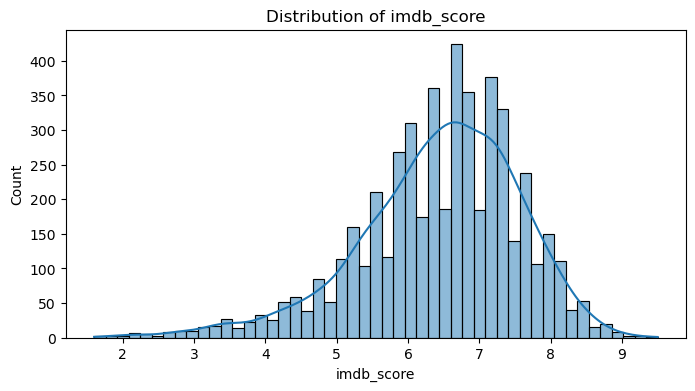

In [28]:
movies_df.plot_distribution("imdb_score")

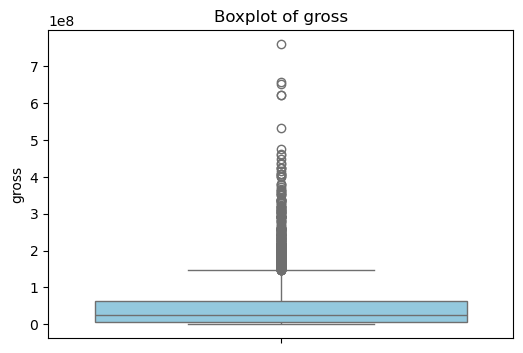

In [30]:
movies_df.box_plot("gross")

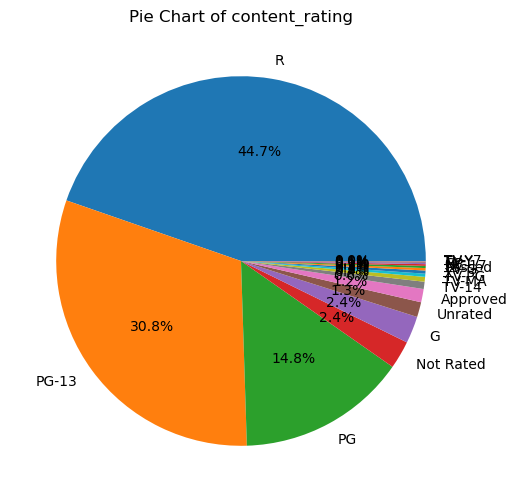

In [31]:
movies_df.plot_pie("content_rating")

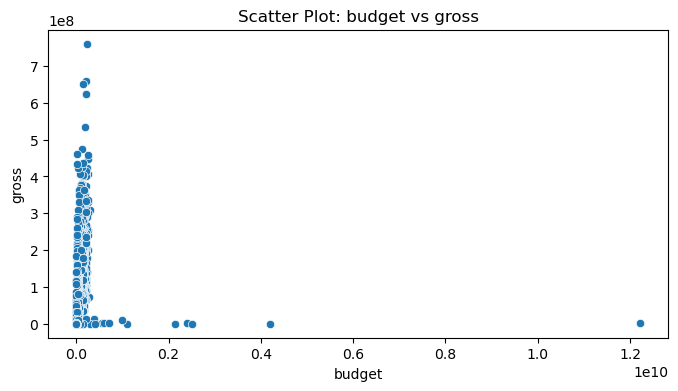

In [33]:
movies_df.plot_scatter("budget", "gross")

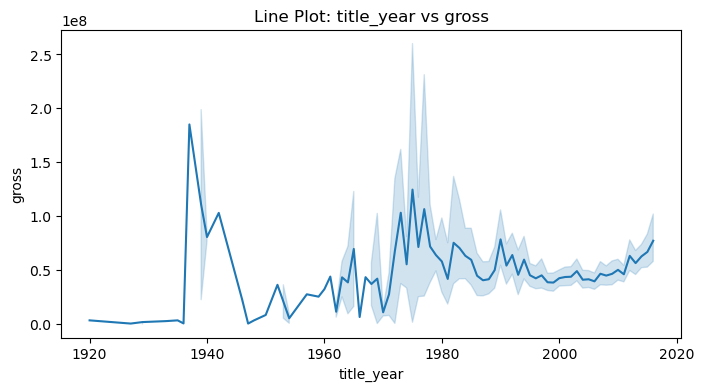

In [34]:
movies_df.plot_line("title_year", "gross")

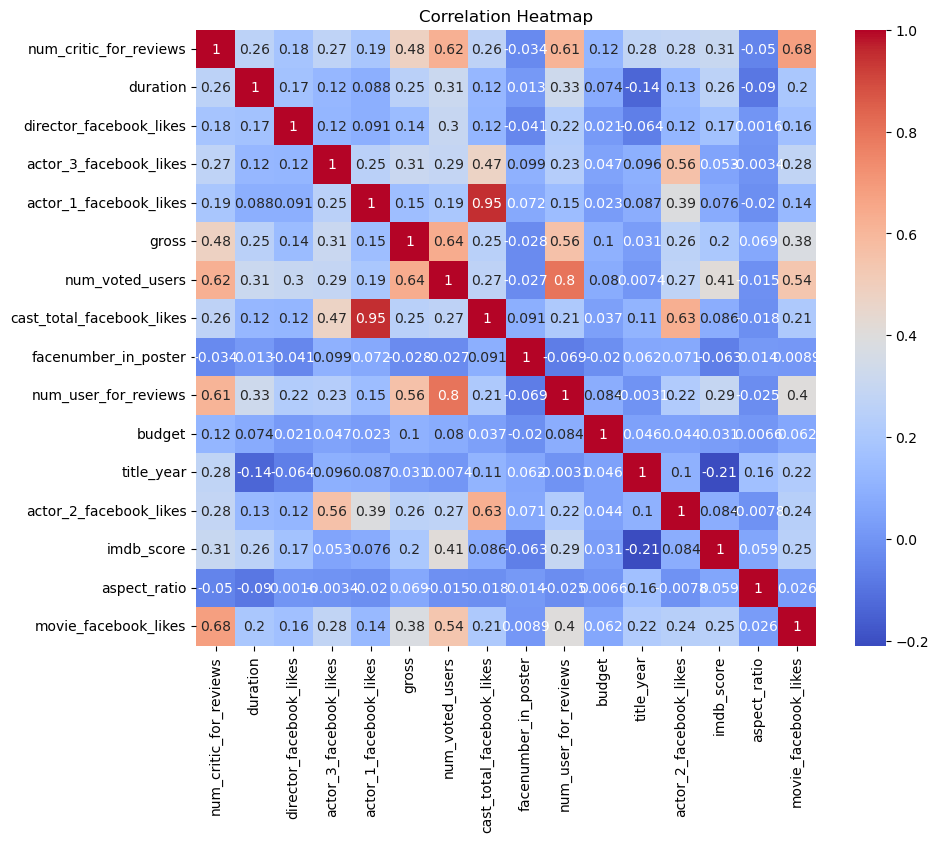

In [35]:
movies_df.correlation_heatmap()

In [36]:
movies_df.chi_square("language", "content_rating")

5.062405965554191e-23

In [37]:
for col1, col2, corr in movies_df.continuous_correlations()[:10]:
    print(f"{col1} vs {col2}: {corr:.3f}")

actor_1_facebook_likes vs cast_total_facebook_likes: 0.952
num_voted_users vs num_user_for_reviews: 0.798
num_critic_for_reviews vs movie_facebook_likes: 0.683
gross vs num_voted_users: 0.637
cast_total_facebook_likes vs actor_2_facebook_likes: 0.628
num_critic_for_reviews vs num_voted_users: 0.625
num_critic_for_reviews vs num_user_for_reviews: 0.609
gross vs num_user_for_reviews: 0.560
actor_3_facebook_likes vs actor_2_facebook_likes: 0.560
num_voted_users vs movie_facebook_likes: 0.538


In [38]:
movies_df.anova_test("imdb_score")

,Feature,ANOVA_p_value
0,color,0.0
1,director_name,0.0
2,actor_2_name,0.0
3,genres,0.0
4,actor_1_name,0.0
5,movie_title,0.0
6,actor_3_name,0.0
7,plot_keywords,0.0
8,movie_imdb_link,0.0
9,language,0.0


In [40]:
try:
    print("\nT-Test p-value:", movies_df.t_test("country", "imdb_score"))
except Exception as e:
    print("T-Test Error:", e)

T-Test Error: T-test is only applicable for binary categorical variables
